#Step 1: Import libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [2]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


#Step 2: Create Winter Dummy Variable by using the pandas version of an if statement. Also create the interaction term.

In [3]:
HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1
1,dt4training,2011-02-28,24552000,686144,0,794,1
2,dt4training,2011-03-31,14804728,416464,0,714,0
3,dt4training,2011-04-30,11265320,324456,1,354,0
4,dt4training,2011-05-31,5945904,151104,72,114,0
5,dt4training,2011-06-30,10379712,479264,239,4,0
6,dt4training,2011-07-31,13617528,708472,486,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0
9,dt4training,2011-10-31,11957032,392328,24,223,0


In [4]:
#interaction term is just our independent variable * dummy variable
HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


In [5]:
dt4training= HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

In [6]:
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0


#Step 3: Build the regression model

In [7]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production', 'winter_DV','winter_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


In [8]:
x_test = dt4testing[['production', 'winter_DV', 'winter_interaction']]
x_test = sm.add_constant(x_test)

model1_assessment = model1.predict(x_test)

#Step 4: Find the first models predicted revenue and use the percent error to find the mape

In [9]:
dt4testing = dt4testing.copy()
dt4testing['M1 predicted rev'] = model1_assessment.values
dt4testing['M1 pct error'] = abs(
    (dt4testing['revenue'] - dt4testing['M1 predicted rev'])
    / dt4testing['revenue']
)


In [10]:
dt4testing['M1 pct error'].mean()

np.float64(0.15896219012848184)

#Step 5: Repeat with Fall Dummy Variable

In [11]:
HS_data['fall_DV'] = np.where(HS_data['date'].dt.month.isin([9,10,11]),1,0)

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction,fall_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0,1
9,dt4training,2011-10-31,11957032,392328,24,223,0,0,1


In [12]:
#interaction term is just our independent variable * dummy variable
HS_data['fall_interaction'] = HS_data['production'] * HS_data['fall_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction,fall_DV,fall_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0,1,567424
9,dt4training,2011-10-31,11957032,392328,24,223,0,0,1,392328


In [13]:
dt4training= HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

In [14]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production', 'fall_DV','fall_interaction']]
x = sm.add_constant(x)

model2 = sm.OLS(y,x).fit()

model2.params

,0
const,6118386.30
production,18.30
fall_DV,-477240.43
fall_interaction,-7.67


In [15]:
x_test = dt4testing[['production', 'fall_DV', 'fall_interaction']]
x_test = sm.add_constant(x_test)

model2_assessment = model2.predict(x_test)

In [16]:
dt4testing = dt4testing.copy()
dt4testing['M2 predicted rev'] = model2_assessment.values
dt4testing['M2 pct error'] = abs(
    (dt4testing['revenue'] - dt4testing['M2 predicted rev'])
    / dt4testing['revenue']
)

In [17]:
dt4testing['M2 pct error'].mean()

np.float64(0.2201698389944771)

#Step 6: Visualize and Compare Responses

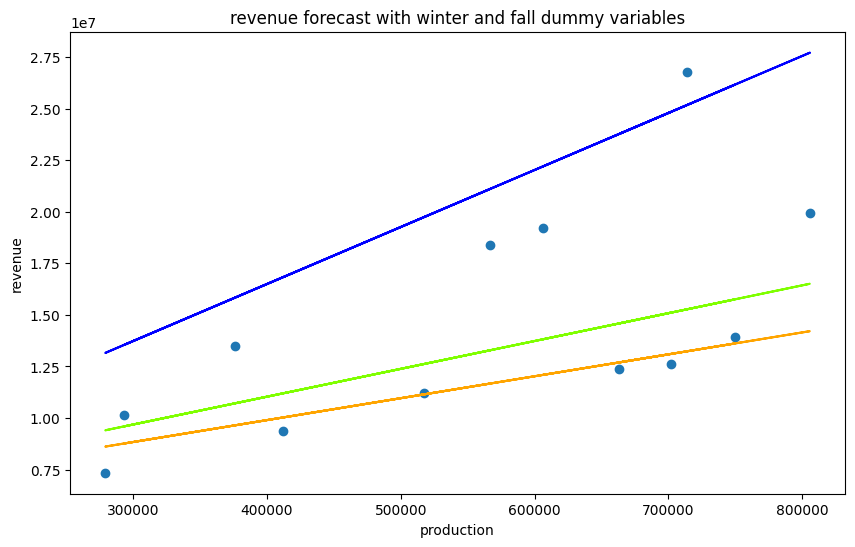

In [19]:
plt.figure(figsize=(10,6))

plt.title('revenue forecast with winter and fall dummy variables')

plt.xlabel('production')
plt.ylabel('revenue')

# step 1 for vsiualizing a regression with dummy variables is to scatter plot the actual datapoints

plt.scatter(dt4testing['production'],dt4testing['revenue'])

# step 2 is to extract the coefficients from our model
intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

intercept_fall, production_coefficient_fall, fall_DV_intercept, fall_coefficient = model2.params

#Step 3 is to create individual lines for winter and non winter
non_winter_line = intercept + production_coefficient * dt4testing['production']

winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4testing['production']

fall_line = (intercept_fall+fall_DV_intercept)+(production_coefficient_fall+fall_coefficient)*dt4testing['production']
#Step 4 plot the y values against the x values for our intercept

plt.plot(dt4testing['production'], non_winter_line, color='chartreuse')
plt.plot(dt4testing['production'], winter_line, color='blue')
plt.plot(dt4testing['production'], fall_line, color='orange')

#Step 7: Share Results to Stakeholders

##MEMO
To: Hotazel Steam
From: Grace Shaw
RE: Hotazel Steam Predicting Revenue


Introduction

Two regression models incorporating seasonal dummy variables were evaluated to determine which provided the most accurate revenue forecasts. The model using a Winter Dummy Variable (DV) achieved a Mean Absolute Percentage Error (MAPE) of approximately 15.90%, while the model using a Fall Dummy Variable (DV) produced an  larger MAPE of 22.02% indicating that it failed to generate meaningful predictions. Based on these results, the Winter Dummy Variable model is the superior forecasting model.

Scope and Methodology

Using the data provided by Hotazel Steam, revenue was modeled as a function of production while incorporating seasonal dummy variables to account for seasonal effects. Separate regression models were developed using a Winter Dummy Variable and a Fall Dummy Variable with interaction terms. The dataset was divided into training and testing subsets, the regression models were estimated using the training data, and predictions were evaluated on the testing data. Model performance was assessed using the Mean Absolute Percentage Error (MAPE), which measures the average percentage difference between predicted and actual revenue.

Key limitations:

Heat Degree Days (Heat DD) were not included in the analysis.
No outlier analysis was performed.
Model performance was evaluated only using the available historical dataset.
Key Findings

1. The Winter Dummy Variable model substantially outperformed the Fall Dummy Variable model.

The Winter Dummy Variable model achieved a MAPE of approximately 15.9%, indicating relatively accurate revenue predictions. In contrast, the Fall Dummy Variable model produced a MAPE of approximately 22.01%, demonstrating worse predictive performance. This suggests that including a Fall Dummy Variable does not adequately explain seasonal variation in revenue and may have resulted in an unstable regression model.

2. Winter appears to have a meaningful impact on revenue forecasting.

The significantly lower prediction error for the Winter Dummy Variable model suggests that winter seasonality has a measurable relationship with revenue. Incorporating winter effects into the regression model improves forecasting accuracy, whereas the Fall Dummy Variable provides little to no predictive value for this dataset.

Recommendations
Use the Winter Dummy Variable model for forecasting revenue, as it produced the lowest prediction error and the most reliable forecasts.
Perform model diagnostics, including residual analysis and outlier detection, to verify that the assumptions of linear regression are satisfied and to identify observations that may be adversely affecting model performance.
Attempt regression models using Spring and Summer as other seasons to see if the produce a better MAPE.